# AML Dataset Initial EDA (of the original dataset)

## Import libraries.

In [ ]:
!pip install torch_geometric

In [ ]:
# Import PyTorch libraries.
import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

In [ ]:
# Import data structure, data manipulation, and data visualization libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [ ]:
# Import model evaluation libraries.
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score
)

In [ ]:
# Mount the drive so we can import files from Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the dataset and overview it.

In [ ]:
# Load the dataset into a dataframe.
data = pd.read_csv('/content/drive/MyDrive/UCLA MASDS/STATS 426: Deep Learning/HI-Small_Trans.csv')
df = data.copy()

In [ ]:
# Get an overview of the dataframe's structure.
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


### Check for the columns' data type correctness and for null values.

In [ ]:
# Show the shape of the dataframe and each column's data type.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [ ]:
# Based on the results of df.info(), several columns should have their data type changed to better reflect their actual purpose.
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['From Bank'] = df['From Bank'].astype('object')
df['To Bank'] = df['To Bank'].astype('object')
df['Is Laundering'] = df['Is Laundering'].astype('object')

In [ ]:
# Check whether the dataframe has missing values.
df.isna().sum()

,0
Timestamp,0
From Bank,0
Account,0
To Bank,0
Account.1,0
Amount Received,0
Receiving Currency,0
Amount Paid,0
Payment Currency,0
Payment Format,0


#### There aren't any null values, so we don't have to impute the data.

### Check for the target variable's imbalance.

In [ ]:
# Check the distribution of the target variable's labels. In our case, 'Is Laundering' is the target variable.
df['Is Laundering'].value_counts(normalize = True)

,proportion
Is Laundering,
0,0.998981
1,0.001019


#### The dataset is heavily imbalanced, so we'll have to account for that when building the model.

## Briefly analyze the data.

In [ ]:
# Here, we check whether accounts are associated with more than a single bank.
acc_banks = df.groupby('Account')['From Bank'].nunique()
acc_multiple_banks = acc_banks[acc_banks > 1]
acc_multiple_banks

,From Bank
Account,
80A7FD400,2
80FA55EF0,2
81211BC00,2
8135B8250,2


In [ ]:
# Among the accounts associated with multiple banks, check whether they engaged in money laundering.
df[df['Account'].isin(('80A7FD400', '80FA55EF0', '81211BC00', '8135B8250'))]['Is Laundering'].value_counts()

,count
Is Laundering,
0,44


In [ ]:
# Obtain summary statistics for the numeric variables, pertaining to non-laundering cases.
df[df['Is Laundering'] == 0].describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,5073168,2022-09-05 07:13:23.156227072,2022-09-01 00:00:00,2022-09-02 04:30:00,2022-09-05 12:13:00,2022-09-08 03:10:00,2022-09-18 11:18:00,NaN
Amount Received,5073168.0,5957962.478735,0.000001,183.07,1407.51,12322.51,1046302363293.47998,1036563448.521215
Amount Paid,5073168.0,4477000.043897,0.000001,184.16,1410.99,12279.34,1046302363293.47998,868846296.804587


In [ ]:
# Obtain summary statistics for the numeric variables, pertaining to laundering cases.
df[df['Is Laundering'] == 1].describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,5177,2022-09-07 04:11:36.171527936,2022-09-01 00:01:00,2022-09-04 11:00:00,2022-09-07 04:10:00,2022-09-09 15:11:00,2022-09-18 16:18:00,NaN
Amount Received,5177.0,36135310.412813,0.003227,2634.97,8667.21,18832.27,84853144179.580002,1527918669.798131
Amount Paid,5177.0,36135310.412813,0.003227,2634.97,8667.21,18832.27,84853144179.580002,1527918669.798131


In [ ]:
categorical_cols = df.select_dtypes(exclude = np.number).columns.tolist()
is_laundering_vals = df['Is Laundering'].unique()
no_yes = {0: 'No', 1: 'Yes'}
for col in categorical_cols:
  print('Column:', col, '\n')
  for val in is_laundering_vals:
    print("Whether laundering is involved:", no_yes[val], '\n')
    print(df[df['Is Laundering'] == val][col].value_counts(normalize = True).head(10))
    print('*' * 50)
  print ('-' * 100, '\n')

Column: Timestamp 

Whether laundering is involved: No 

Timestamp
2022-09-01 00:04:00    0.002206
2022-09-01 00:26:00    0.002173
2022-09-01 00:17:00    0.002172
2022-09-01 00:14:00    0.002169
2022-09-01 00:29:00    0.002168
2022-09-01 00:28:00    0.002165
2022-09-01 00:00:00    0.002164
2022-09-01 00:19:00    0.002160
2022-09-01 00:05:00    0.002159
2022-09-01 00:06:00    0.002157
Name: proportion, dtype: float64
**************************************************
Whether laundering is involved: Yes 

Timestamp
2022-09-04 12:17:00    0.000773
2022-09-03 08:52:00    0.000773
2022-09-06 11:14:00    0.000773
2022-09-09 12:07:00    0.000773
2022-09-08 12:43:00    0.000773
2022-09-02 08:55:00    0.000773
2022-09-05 11:45:00    0.000773
2022-09-02 17:50:00    0.000579
2022-09-01 17:54:00    0.000579
2022-09-10 10:49:00    0.000579
Name: proportion, dtype: float64
**************************************************
-----------------------------------------------------------------------------

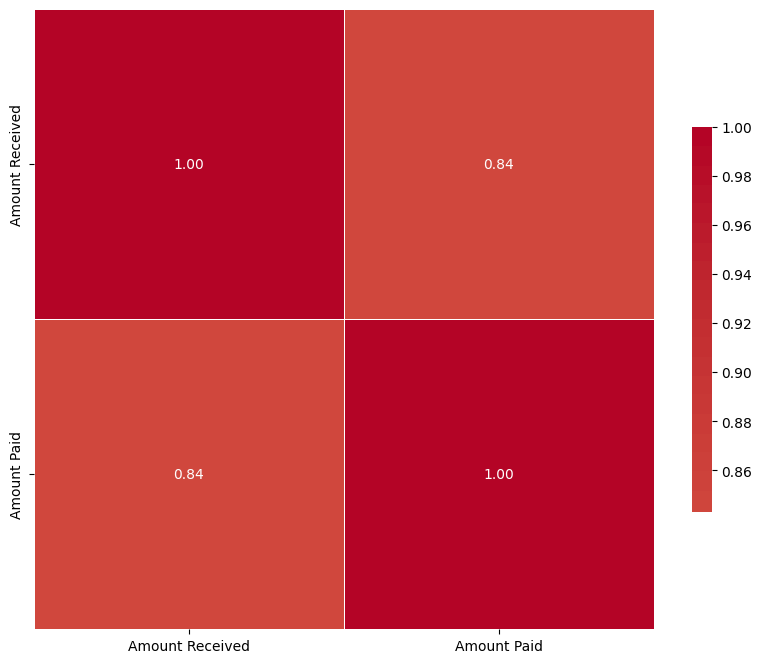

In [ ]:
df_no_label = df.drop('Is Laundering', axis = 1)
corr_matrix = df_no_label.corr(numeric_only = True)

plt.figure(figsize = (10, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=.5, square = True, cbar_kws={"shrink": .5})
plt.show()



In [ ]:
Q1 = df['Amount Received'].quantile(0.25)
Q3 = df['Amount Received'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_temp_num = df[(df['Amount Received'] >= lower_bound) & (df['Amount Received'] <= upper_bound)]


In [ ]:
x

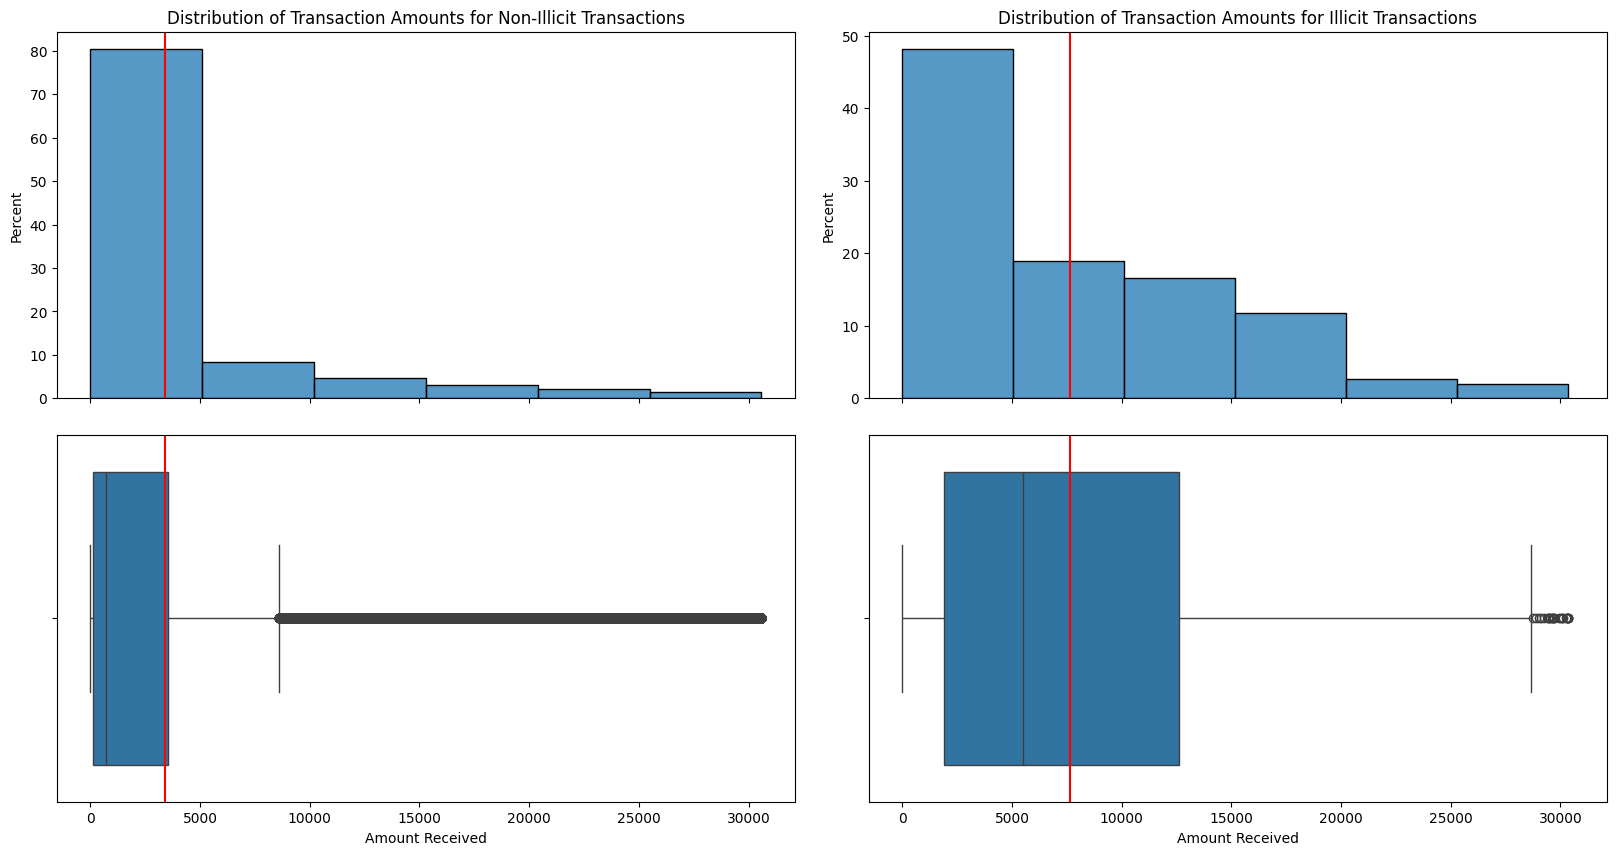

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (20, 10), sharex = True)

ax0 = sns.histplot(df_temp_num[df_temp_num['Is Laundering'] == 0], x = 'Amount Received', bins = 6, stat = 'percent', ax = ax[0,0])
ax[0, 0].set_title('Distribution of Transaction Amounts for Non-Illicit Transactions')
ax[0, 0].axvline(df_temp_num[df_temp_num['Is Laundering'] == 0]['Amount Received'].mean(), color = 'red')

ax1 = sns.histplot(df_temp_num[df_temp_num['Is Laundering'] == 1], x = 'Amount Received', bins = 6, stat = 'percent', ax = ax[0,1])
ax[0, 1].set_title('Distribution of Transaction Amounts for Illicit Transactions')
ax[0, 1].axvline(df_temp_num[df_temp_num['Is Laundering'] == 1]['Amount Received'].mean(), color = 'red')

sns.boxplot(x = 'Amount Received', data = df_temp_num[df_temp_num['Is Laundering'] == 0], ax = ax[1,0])
ax[1, 0].axvline(df_temp_num[df_temp_num['Is Laundering'] == 0]['Amount Received'].mean(), color = 'red')

sns.boxplot(x = 'Amount Received', data = df_temp_num[df_temp_num['Is Laundering'] == 1], ax = ax[1,1])
ax[1, 1].axvline(df_temp_num[df_temp_num['Is Laundering'] == 1]['Amount Received'].mean(), color = 'red')

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

/tmp/ipykernel_2407/3040552241.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cross_table = pd.crosstab(index=filtered_df[df['Is Laundering'] == 0]['Receiving Currency'], columns=filtered_df[df['Is Laundering'] == 0]['Payment Format'], normalize='index')
/tmp/ipykernel_2407/3040552241.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cross_table = pd.crosstab(index=filtered_df[df['Is Laundering'] == 0]['Receiving Currency'], columns=filtered_df[df['Is Laundering'] == 0]['Payment Format'], normalize='index')
/tmp/ipykernel_2407/3040552241.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cross_table2 = pd.crosstab(index=filtered_df2[df['Is Laundering'] == 1]['Receiving Currency'], columns=filtered_df2[df['Is Laundering'] == 1]['Payment Format'], normalize='index')
/tmp/ipykernel_2407/3040552241.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cr

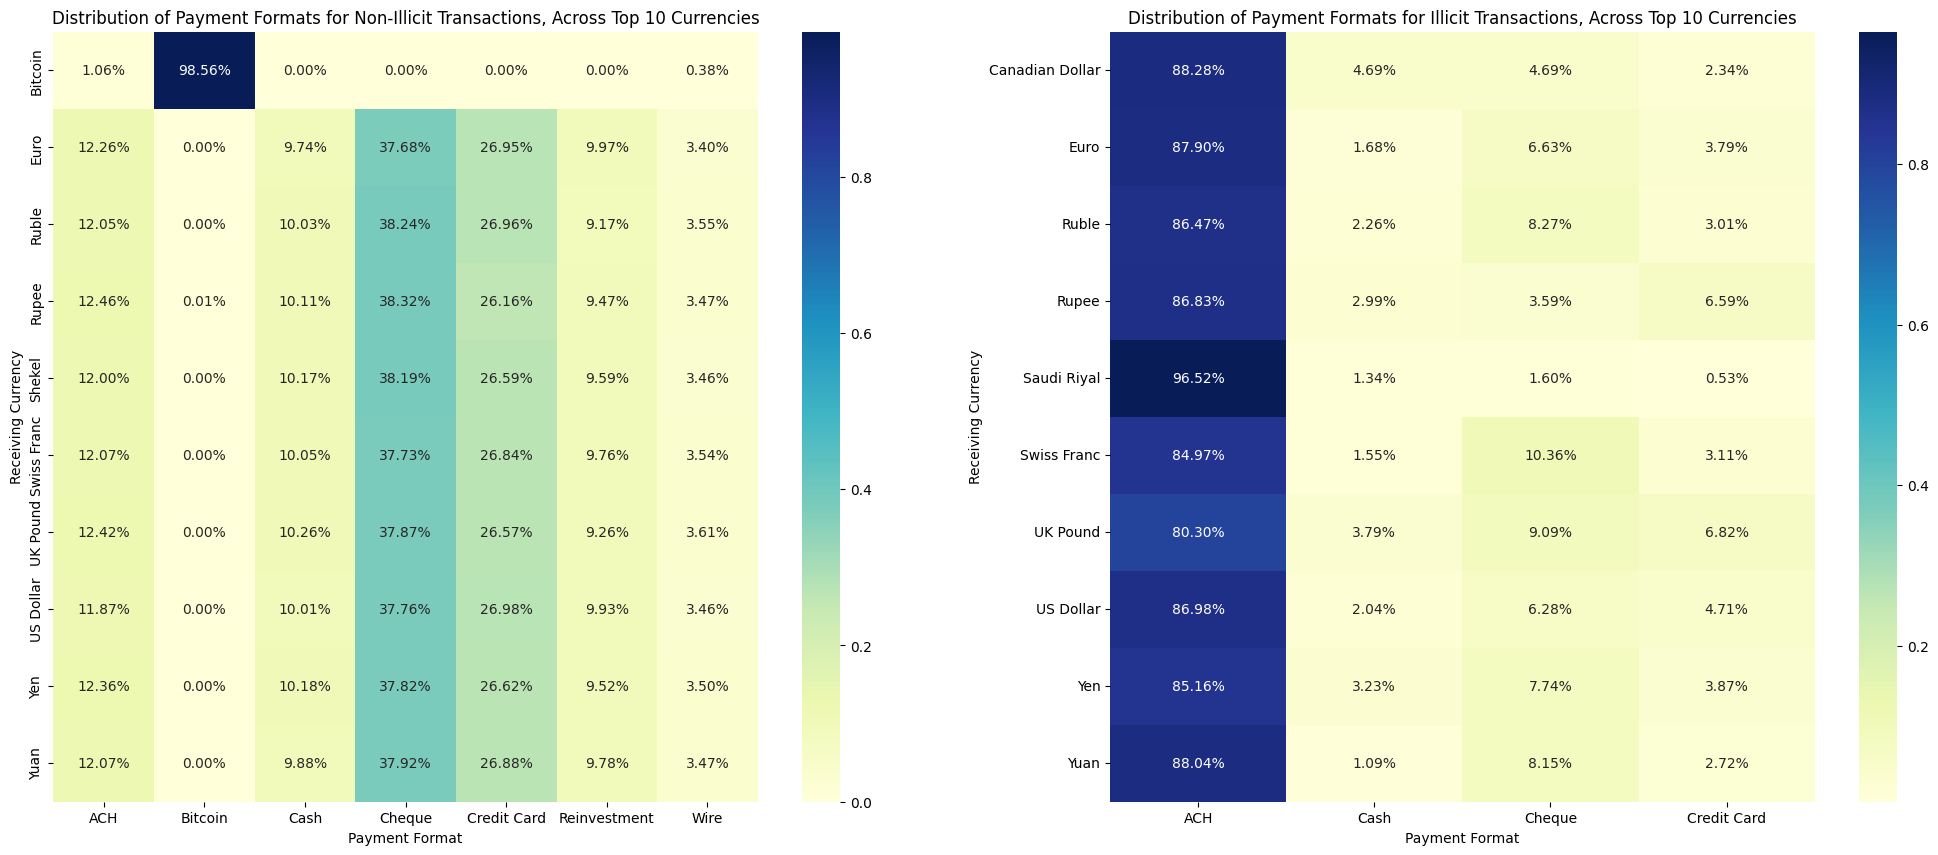

In [ ]:
top_currencies_table_benign = df[df['Is Laundering'] == 0]['Receiving Currency'].value_counts(normalize = True).head(10)
top_currencies_table_illicit = df[df['Is Laundering'] == 1]['Receiving Currency'].value_counts(normalize = True).head(10)

currencies_list_benign = top_currencies_table_benign.index.tolist()
currencies_list_illicit = top_currencies_table_illicit.index.tolist()

filtered_df = df[df['Receiving Currency'].isin(currencies_list_benign)]
filtered_df2 = df[df['Receiving Currency'].isin(currencies_list_illicit)]

cross_table = pd.crosstab(index=filtered_df[df['Is Laundering'] == 0]['Receiving Currency'], columns=filtered_df[df['Is Laundering'] == 0]['Payment Format'], normalize='index')
cross_table2 = pd.crosstab(index=filtered_df2[df['Is Laundering'] == 1]['Receiving Currency'], columns=filtered_df2[df['Is Laundering'] == 1]['Payment Format'], normalize='index')

fig, ax = plt.subplots(1, 2, figsize = (25, 10))
sns.heatmap(cross_table, annot=True, cmap="YlGnBu", fmt=".2%", ax = ax[0])
sns.heatmap(cross_table2, annot = True, cmap="YlGnBu", fmt=".2%", ax = ax[1])

ax[0].set_title('Distribution of Payment Formats for Non-Illicit Transactions, Across Top 10 Currencies')
ax[1].set_title('Distribution of Payment Formats for Illicit Transactions, Across Top 10 Currencies')
plt.show()

/tmp/ipykernel_2407/585920560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_currencies_table_benign, palette='viridis', ax = ax[0])
/tmp/ipykernel_2407/585920560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(top_currencies_table_illicit, palette='viridis', ax = ax[1])


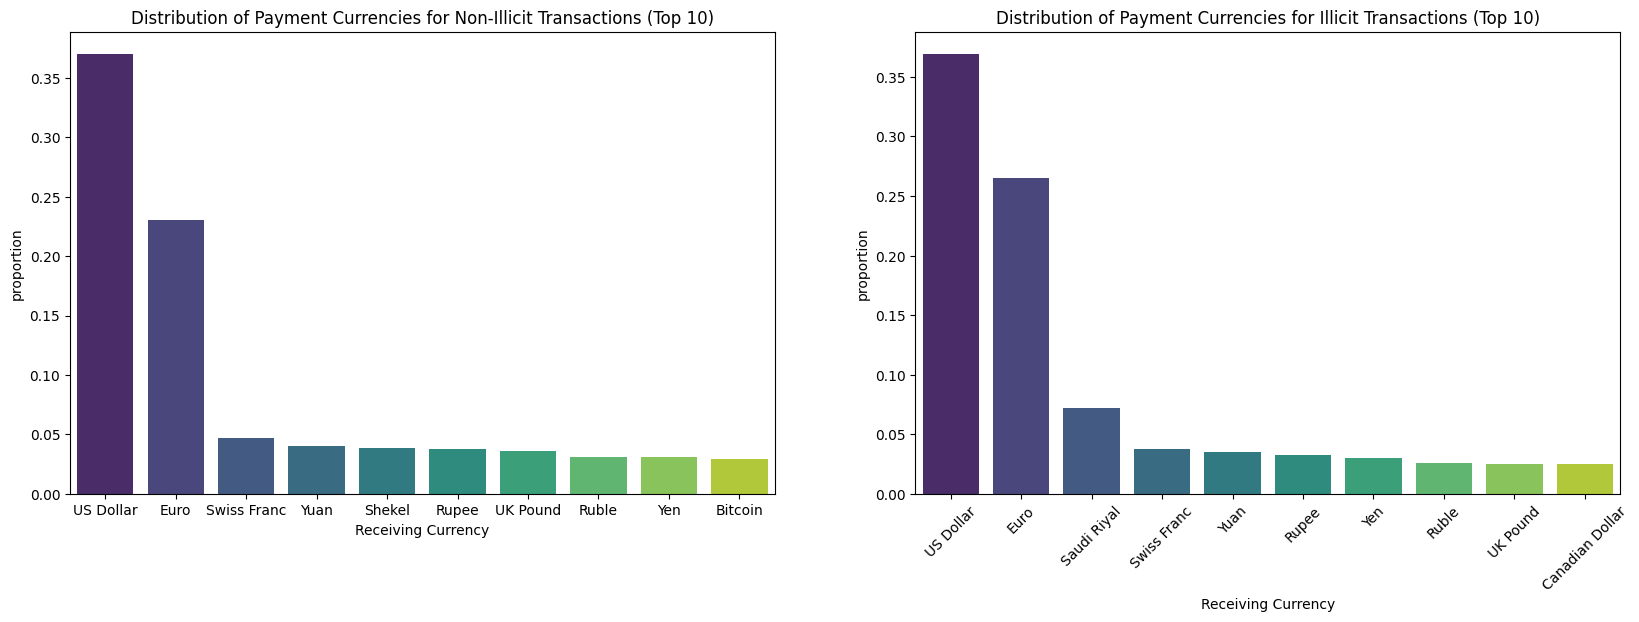

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (20, 6))
sns.barplot(top_currencies_table_benign, palette='viridis', ax = ax[0])
sns.barplot(top_currencies_table_illicit, palette='viridis', ax = ax[1])
ax[0].set_title('Distribution of Payment Currencies for Non-Illicit Transactions (Top 10)')
ax[1].set_title('Distribution of Payment Currencies for Illicit Transactions (Top 10)')
plt.xticks(rotation=45)
plt.show()